In [1]:
!pip install numpy
!pip install torch
!pip install -q tqdm
!pip install matplotlib

In [2]:
import numpy as np
import torch
import torch.nn as nn
from tqdm import tqdm
from matplotlib import pyplot as plt

In [3]:
class FourierFeatureMapping(nn.Module):
    def __init__(self, input_dim, mapping_size, scale=10.0):
        super().__init__()
        # B matrix contains random frequencies sampled from a Gaussian distribution
        # The 'scale' (sigma) dictates the highest frequencies the network can resolve
        self.register_buffer('B', torch.randn(input_dim, mapping_size) * scale)
        
    def forward(self, x):
        # x shape: [batch_size, input_dim]
        # Compute projection: 2 * pi * x @ B
        projection = 2 * np.pi * torch.matmul(x, self.B)
        # Concatenate sin and cos components to retain full phase information
        return torch.cat([torch.sin(projection), torch.cos(projection)], dim=-1)

In [26]:
class FourierPsiPINN(nn.Module):
    def __init__(self, input_dim=2, mapping_size=128, hidden_dim=256):
        super().__init__()
        self.fourier_layer = FourierFeatureMapping(input_dim, mapping_size, scale=5.0)
        
        # Input dimension to the first linear layer is double the mapping size due to sin/cos cat
        self.mlp = nn.Sequential(
            nn.Linear(mapping_size * 2, hidden_dim),
            nn.Tanh(), # Tanh works beautifully after a Fourier mapping
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 2)
        )
        
    def forward(self, x, t):
        inputs = torch.cat([x, t], dim=1)
        embedded_coords = self.fourier_layer(inputs)
        results = self.mlp(embedded_coords)
        return results[:, 0], results[:, 1]

In [5]:
def compute_schrodinger_equation_residue(model, x, t, m, hbar):
    psiR, psiI = model(x, t)

    psiR_t = torch.autograd.grad(psiR, t, torch.ones_like(psiR), create_graph=True, retain_graph=True)[0]
    psiI_t = torch.autograd.grad(psiI, t, torch.ones_like(psiI), create_graph=True, retain_graph=True)[0]

    psiR_x = torch.autograd.grad(psiR, x, torch.ones_like(psiR), create_graph=True, retain_graph=True)[0]
    psiR_xx = torch.autograd.grad(psiR_x, x, torch.ones_like(psiR_x), create_graph=True, retain_graph=True)[0]
    psiI_x = torch.autograd.grad(psiI, x, torch.ones_like(psiI), create_graph=True, retain_graph=True)[0]
    psiI_xx = torch.autograd.grad(psiI_x, x, torch.ones_like(psiI_x), create_graph=True, retain_graph=True)[0]

    residue_0 = -0.5*hbar*hbar/m * psiR_xx + hbar * psiI_t
    residue_1 = -0.5*hbar*hbar/m * psiI_xx - hbar * psiR_t
    return torch.square(residue_0).mean(), torch.square(residue_1).mean()

In [7]:
def analytical_solution(x, t, A, hbar, m, L):
    psi = A * np.sin(np.pi*x/L) * np.exp(-0.5*L*L*hbar/m*t*1.j)
    return np.real(psi), np.imag(psi)

In [10]:
device = torch.device("cuda")

In [21]:
n_colloc, n_bc = 5000, 200
epochs = 5000
hbar = 1.
m = 1.
L = 1.

In [22]:
x_colloc = torch.rand(n_colloc, 1, requires_grad=True).to(device)
t_colloc = torch.Tensor(4*np.pi*torch.rand(n_colloc, 1)).to(device)
t_colloc.requires_grad_()

# initial condition
x_ic = torch.rand(n_bc, 1).to(device)
t_ic = torch.zeros(n_bc, 1).to(device)
psiR_ic, psiI_ic = analytical_solution(x_ic.cpu().numpy(), t_ic.cpu().numpy(), 1., 1., 1., 1.)
psiR_ic = torch.FloatTensor(psiR_ic).to(device)
psiI_ic = torch.FloatTensor(psiI_ic).to(device)

# boundary conditions
x_bc = torch.cat([torch.zeros(n_bc // 2, 1), torch.ones(n_bc // 2, 1) * L]).to(device)
t_bc = torch.rand(n_bc, 1).to(device)
psiR_bc, psiI_bc = torch.zeros(n_bc, 1).to(device), torch.zeros(n_bc, 1).to(device)

In [27]:
pinn = FourierPsiPINN().to(device)
optimizer = torch.optim.Adam(pinn.parameters(), lr=1e-3)

In [28]:
losses_pde_R = []
losses_pde_I = []
losses_ic_R = []
losses_ic_I = []
losses_bc_R = []
losses_bc_I = []
losses = []

In [29]:
for epoch in tqdm(range(epochs)):
    optimizer.zero_grad()

    loss_pde_R, loss_pde_I = compute_schrodinger_equation_residue(pinn, x_colloc, t_colloc, 1., 1.)
    pinn_ic_R, pinn_ic_I = pinn(x_ic, t_ic)
    loss_ic_R = nn.functional.mse_loss(pinn_ic_R.flatten()[:, None], psiR_ic)
    loss_ic_I = nn.functional.mse_loss(pinn_ic_I.flatten()[:, None], psiI_ic)
    pinn_bc_R, pinn_bc_I = pinn(x_bc, t_bc)
    loss_bc_R = nn.functional.mse_loss(pinn_bc_R.flatten()[:, None], psiR_bc)
    loss_bc_I = nn.functional.mse_loss(pinn_bc_I.flatten()[:, None], psiI_bc)

    loss = loss_pde_R + loss_pde_I + 10 * loss_ic_R + 10 * loss_ic_I + 10 * loss_bc_R + 10 * loss_bc_I

    loss.backward()
    optimizer.step()

    losses_pde_R.append(loss_pde_R.item())
    losses_pde_I.append(loss_pde_I.item())
    losses_ic_R.append(loss_ic_R.item())
    losses_ic_I.append(loss_ic_I.item())
    losses_bc_R.append(loss_bc_R.item())
    losses_bc_I.append(loss_bc_I.item())
    losses.append(loss.item())

    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch}: {loss.item():.2f}")

 11%|█         | 528/5000 [00:02<00:21, 212.09it/s]

Epoch 499: 2.80


 21%|██        | 1034/5000 [00:05<00:18, 211.89it/s]

Epoch 999: 1.85


 31%|███       | 1540/5000 [00:07<00:16, 211.75it/s]

...

Epoch 3999: 0.03


 91%|█████████ | 4532/5000 [00:21<00:02, 211.01it/s]

Epoch 4499: 0.05


100%|██████████| 5000/5000 [00:23<00:00, 208.72it/s]

Epoch 4999: 0.02


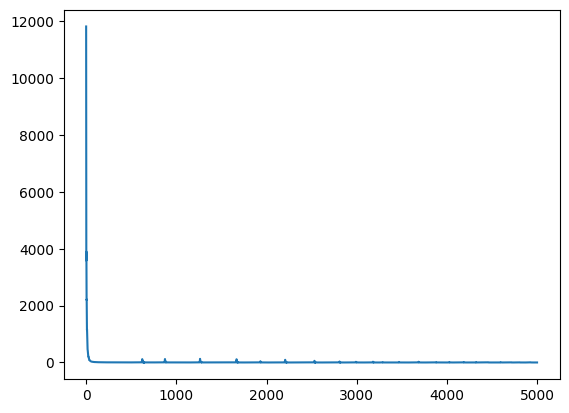

In [30]:
plt.plot(range(epochs), losses)

In [31]:
with torch.no_grad():
    x_test = torch.linspace(0., 1., 100).flatten()[:, None].to(device)
    psi = pinn(x_test, 0.1*torch.ones(100).flatten()[:, None].to(device))

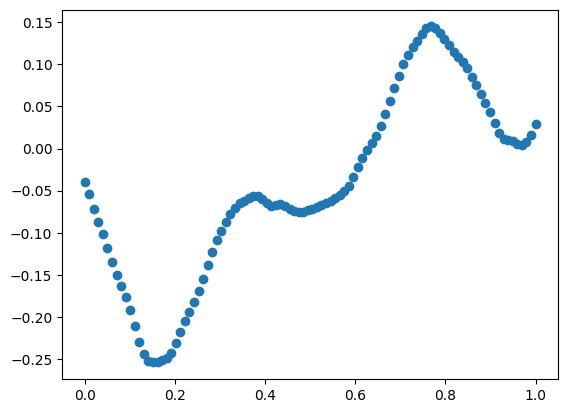

In [32]:
plt.scatter(x_test.cpu().numpy(), psi[0].cpu().numpy())

In [33]:
with torch.no_grad():
    t_test = torch.linspace(0, 4*torch.pi, 100).to(device).flatten()[:, None]
    x_test = torch.ones(100).to(device).flatten()[:, None] * 0.5
    psi = pinn(x_test, t_test)

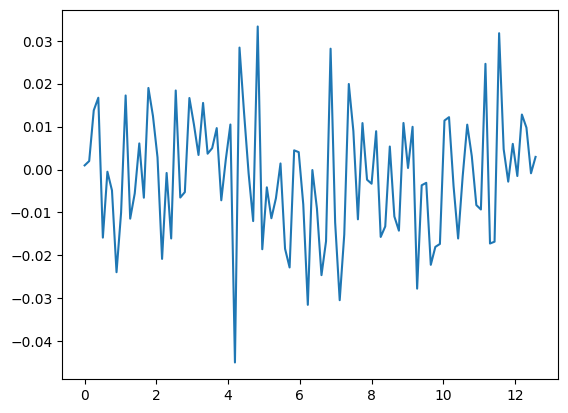

In [34]:
plt.plot(t_test.cpu().numpy(), psi[1].cpu().numpy())